# Week 3 Capstone: validated cumulative review

## Table of contents

1. [Overview](#overview)
2. [Objectives](#objectives)
3. [Evidence provenance](#evidence-provenance)
4. [Environment and setup](#environment-setup)
5. [Data validation](#data-validation)
6. [Descriptive EDA](#descriptive-eda)
7. [Visual EDA](#visual-eda)
8. [GP model configuration](#gp-model-configuration)
9. [GP-UCB values](#gp-ucb-values)
10. [Reproducibility checks](#reproducibility-checks)
11. [Conclusions and next steps](#conclusions-next-steps)

<a id="overview"></a>
## 1. Overview

This notebook reconstructs the Week 3 evidence from confirmed starter data plus the recorded Week 1 and Week 2 submissions. It reviews F1–F8 independently, proposes reproducible next queries, and renders complete Matplotlib diagnostics.

<a id="objectives"></a>
## 2. Objectives

Validate the Week 3 evidence, review F1–F8, document the acquisition strategy, generate reproducible recommendations, and verify every output.

<a id="evidence-provenance"></a>
## 3. Evidence provenance

1. `initial_data.zip` does not exist; the repository already contains the starter arrays under `Week_01/Function_nn/03_Data`.
2. F8's Week 1 input had six coordinates although F8 is eight-dimensional. `fix_dimension()` silently invented two `0.5` coordinates. The exact eight-dimensional recorded query is restored.
3. Silent padding/truncation could corrupt any observation. Incorrect dimensions now raise an explicit error.
4. The notebook recursively deleted `week_3_data` and depended on generated files from earlier cells. Data is now reconstructed deterministically in memory.
5. `google.colab.files` is unavailable outside Colab and downloading a generated archive is unrelated to analysis, so those cells were removed.
6. Duplicate plot loops used inconsistent zero- and one-based query numbering. One consistent plotting function replaces them.
7. GP kernels, uncertainty, and UCB scores were discarded. The proposal routine now returns and reports them.
8. Global random state made results depend on execution order. Function-specific generators make proposals reproducible.
9. Missing shape, finiteness, domain, historical-round, and proposal checks are now enforced.

<a id="environment-setup"></a>
## 4. Environment and setup

Initialise paths, dependencies, dimensions, evidence mappings, and reusable analysis helpers.

In [1]:
from pathlib import Path
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel

FUNCTIONS = tuple(range(1, 9))
DIMENSIONS = {1: 2, 2: 2, 3: 3, 4: 4, 5: 4, 6: 5, 7: 6, 8: 8}
STRATEGY = {i: ('Manual Reasoning' if i == 5 else 'Bayesian Optimisation') for i in FUNCTIONS}
KAPPA = {1: 5.0, 2: 5.0, 3: 5.0, 4: 5.0, 6: 5.0, 7: 2.0, 8: 5.0}

ROUND_QUERIES = {
  1: {1: [0.375440, 0.950714], 2: [0.536429, 0.835362]},
  2: {1: [0.375440, 0.950714], 2: [0.978752, 0.932731]},
  3: {1: [0.444444, 0.666666, 0.333333], 2: [0.657452, 0.998464, 0.817253]},
  4: {1: [0.555555, 0.444444, 0.222222, 0.111111], 2: [0.006280, 0.281840, 0.932013, 0.960202]},
  5: {1: [0.224189, 0.846480, 0.879484, 0.878515], 2: [0.255841, 0.841692, 0.888984, 0.860260]},
  6: {1: [0.728186, 0.154693, 0.732552, 0.693997, 0.564013], 2: [0.433654, 0.486678, 0.282753, 0.972905, 0.323321]},
  7: {1: [0.045091, 0.528666, 0.329265, 0.105350, 0.434667, 0.641164], 2: [0.243848, 0.900100, 0.696978, 0.193630, 0.374149, 0.826324]},
  8: {1: [0.273673, 0.260400, 0.073937, 0.078562, 0.862321, 0.230729, 0.106880, 0.352588], 2: [0.163160, 0.184786, 0.152644, 0.083802, 0.999322, 0.544113, 0.184124, 0.123846]},
}
ROUND_OUTPUTS = {
  1: {1: -1.560646704467778e-117, 2: 1.674933466363685e-36},
  2: {1: -0.03182956281754251, 2: 0.022666631114895516},
  3: {1: -0.04090761844901528, 2: -0.08987474979637637},
  4: {1: -8.727516493155957, 2: -31.73535839431216},
  5: {1: 1088.8535114737463, 2: 1035.6341457754475},
  6: {1: -1.1520351120911565, 2: -0.8782405650300305},
  7: {1: 1.0510148516295004, 2: 0.308765180253091},
  8: {1: 9.8157087929671, 2: 9.9399041910574},
}

def repository_root(start=None):
    current = Path.cwd() if start is None else Path(start).expanduser().resolve()
    for candidate in (current, *current.parents):
        if all((candidate / f'Week_{week:02d}').is_dir() for week in (1, 2, 3)):
            return candidate
    raise FileNotFoundError('Could not find the capstone repository root.')

ROOT = repository_root()
plt.style.use('seaborn-v0_8-whitegrid')
print(f'Repository root: {ROOT}')

Matplotlib is building the font cache; this may take a moment.


Repository root: /Users/john-peteramewu/Documents/GitHub/My_Capstone_1_Imperial


In [2]:
def validate(function_number, X, y):
    if X.ndim != 2 or X.shape[1] != DIMENSIONS[function_number]:
        raise ValueError(f'F{function_number}: expected (*, {DIMENSIONS[function_number]}) inputs, got {X.shape}.')
    if y.ndim != 1 or X.shape[0] != y.size or not y.size:
        raise ValueError(f'F{function_number}: input/output counts must match and be non-empty.')
    if not np.isfinite(X).all() or not np.isfinite(y).all():
        raise ValueError(f'F{function_number}: data contains NaN or infinity.')
    if np.any((X < 0) | (X > 1)):
        raise ValueError(f'F{function_number}: inputs must lie in [0, 1].')

def starter_files(function_number):
    folder = ROOT / 'Week_01' / f'Function_{function_number:02d}' / '03_Data'
    files = folder / 'initial_inputs.npy', folder / 'initial_outputs.npy'
    missing = [str(path) for path in files if not path.is_file()]
    if missing:
        raise FileNotFoundError('Missing starter data: ' + ', '.join(missing))
    return files

def load_week_3_data(function_number):
    if function_number not in FUNCTIONS:
        raise ValueError(f'function_number must be 1..8, got {function_number!r}')
    input_file, output_file = starter_files(function_number)
    X = np.asarray(np.load(input_file), dtype=float)
    y = np.asarray(np.load(output_file), dtype=float).reshape(-1)
    validate(function_number, X, y)
    for round_number in (1, 2):
        query = np.asarray(ROUND_QUERIES[function_number][round_number], dtype=float)
        if query.shape != (DIMENSIONS[function_number],):
            raise ValueError(f'F{function_number}, round {round_number}: expected {DIMENSIONS[function_number]} coordinates, got {query.size}.')
        X = np.vstack((X, query))
        y = np.append(y, float(ROUND_OUTPUTS[function_number][round_number]))
    validate(function_number, X, y)
    return X, y

<a id="data-validation"></a>
## 5. Data validation

Apply the notebook's shape, bounds, finiteness, alignment, and evidence-count checks before interpretation.

<a id="descriptive-eda"></a>
## 6. Descriptive EDA

The newest observation is the Week 2 submission returned for Week 3. Improvement is measured against all starter and Week 1 observations. Percentile is calculated within the previous observations, making it comparable despite different objective scales.

In [3]:
def summarize(function_number):
    X, y = load_week_3_data(function_number)
    previous, newest = y[:-1], float(y[-1])
    best_index = int(np.argmax(y))
    return {'Function': f'F{function_number}', 'Strategy': STRATEGY[function_number],
            'Dimensions': X.shape[1], 'Observation count': y.size,
            'Previous best': float(np.max(previous)), 'New observation': newest,
            'New best': float(np.max(y)), 'Improvement': float(np.max(y) - np.max(previous)),
            'New-observation percentile': 100.0 * float(np.mean(previous <= newest)),
            'Best query': best_index + 1, 'Best input': X[best_index].tolist()}

performance_summary = pd.DataFrame([summarize(i) for i in FUNCTIONS])
performance_summary

,Function,Strategy,Dimensions,Observation count,Previous best,New observation,New best,Improvement,New-observation percentile,Best query,Best input
0,F1,Bayesian Optimisation,2,12,7.710875e-16,1.674933e-36,7.710875e-16,0.000000,90.909091,3,"[0.7310236309563586, 0.7329998764152272]"
1,F2,Bayesian Optimisation,2,12,6.112052e-01,2.266663e-02,6.112052e-01,0.000000,27.272727,10,"[0.7026365569244406, 0.9265641975455574]"
2,F3,Bayesian Optimisation,3,17,-3.483531e-02,-8.987475e-02,-3.483531e-02,0.000000,56.250000,4,"[0.49258141463713434, 0.6115931882759961, 0.34..."
3,F4,Bayesian Optimisation,4,32,-4.025542e+00,-3.173536e+01,-4.025542e+00,0.000000,3.225806,28,"[0.5777656143780968, 0.4287717415443063, 0.425..."
4,F5,Manual Reasoning,4,22,1.088860e+03,1.035634e+03,1.088860e+03,0.000000,90.476190,16,"[0.22418902330288348, 0.8464804904862864, 0.87..."
5,F6,Bayesian Optimisation,5,22,-7.142649e-01,-8.782406e-01,-7.142649e-01,0.000000,90.476190,1,"[0.7281861047460138, 0.1546925696237983, 0.732..."
6,F7,Bayesian Optimisation,6,32,1.364968e+00,3.087652e-01,1.364968e+00,0.000000,74.193548,7,"[0.057895541971385245, 0.49167221863901367, 0...."
7,F8,Bayesian Optimisation,8,42,9.815709e+00,9.939904e+00,9.939904e+00,0.124195,100.000000,42,"[0.16316, 0.184786, 0.152644, 0.083802, 0.9993..."


In [4]:
for row in performance_summary.to_dict('records'):
    status = 'IMPROVED' if row['Improvement'] > 0 else 'NO NEW BEST'
    print(f"{row['Function']} — {row['Strategy']} — {status}")
    print(f"  observations={row['Observation count']}, dimensions={row['Dimensions']}")
    print(f"  previous best={row['Previous best']:.12g}, new observation={row['New observation']:.12g}")
    print(f"  new best={row['New best']:.12g}, improvement={row['Improvement']:.12g}")
    print(f"  best query={row['Best query']}, best input={np.asarray(row['Best input'])}")

F1 — Bayesian Optimisation — NO NEW BEST
  observations=12, dimensions=2
  previous best=7.7108751145e-16, new observation=1.67493346636e-36
  new best=7.7108751145e-16, improvement=0
  best query=3, best input=[0.73102363 0.73299988]
F2 — Bayesian Optimisation — NO NEW BEST
  observations=12, dimensions=2
  previous best=0.611205215761, new observation=0.0226666311149
  new best=0.611205215761, improvement=0
  best query=10, best input=[0.70263656 0.9265642 ]
F3 — Bayesian Optimisation — NO NEW BEST
  observations=17, dimensions=3
  previous best=-0.0348353133501, new observation=-0.0898747497964
  new best=-0.0348353133501, improvement=0
  best query=4, best input=[0.49258141 0.61159319 0.34017639]
F4 — Bayesian Optimisation — NO NEW BEST
  observations=32, dimensions=4
  previous best=-4.02554228191, new observation=-31.7353583943
  new best=-4.02554228191, improvement=0
  best query=28, best input=[0.57776561 0.42877174 0.42582587 0.24900741]
F5 — Manual Reasoning — NO NEW BEST
  o

<a id="visual-eda"></a>
## 7. Visual EDA

Review the observed trajectories and diagnostic intent before fitting the next-query model.

<a id="gp-model-configuration"></a>
## 8. GP model configuration

F1–F4 and F6–F8 use GP-UCB; F5 retains local manual exploration. Every proposal is in bounds, distinct from prior observations, and linked to the diagnostics actually produced.

In [5]:
def manual_query(X, y, rng, scale=0.05):
    centre = X[int(np.argmax(y))]
    for _ in range(100):
        query = np.clip(centre + rng.normal(0, scale, centre.shape), 0, 1)
        if not np.any(np.all(np.isclose(X, query, rtol=0, atol=1e-12), axis=1)):
            return {'query': query, 'kernel': 'Manual reasoning', 'std': np.nan, 'ucb': np.nan}
    raise RuntimeError('Could not produce a distinct manual query.')

def bayesian_query(X, y, kappa, rng, candidates=5000):
    dimension = X.shape[1]
    kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(np.ones(dimension), (1e-2, 1e2)) + WhiteKernel(1e-5, (1e-10, 1e1))
    gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=3, random_state=42)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', ConvergenceWarning)
        gp.fit(X, y)
    points = rng.uniform(0, 1, (candidates, dimension))
    mean, std = gp.predict(points, return_std=True)
    ucb = mean + kappa * std
    selected = int(np.argmax(ucb))
    return {'query': points[selected], 'kernel': str(gp.kernel_), 'std': float(std[selected]), 'ucb': float(ucb[selected])}

<a id="gp-ucb-values"></a>
## 9. GP-UCB values

Generate and display the exact proposed queries, fitted kernels, predictive uncertainty, and acquisition values, followed by their supporting diagnostics.

In [6]:
submission_queries, proposal_rows = {}, []
for function_number in FUNCTIONS:
    X, y = load_week_3_data(function_number)
    rng = np.random.default_rng(300 + function_number)
    kappa = np.nan if function_number == 5 else KAPPA[function_number]
    result = manual_query(X, y, rng) if function_number == 5 else bayesian_query(X, y, kappa, rng)
    query = np.asarray(result['query'])
    assert query.shape == (DIMENSIONS[function_number],) and np.all((query >= 0) & (query <= 1))
    assert not np.any(np.all(np.isclose(X, query, rtol=0, atol=1e-12), axis=1))
    submission_queries[function_number] = query
    proposal_rows.append({'Function': f'F{function_number}', 'Method': STRATEGY[function_number], 'Kappa': kappa,
                          'Proposed query': query.tolist(), 'Fitted kernel': result['kernel'],
                          'Predictive std': result['std'], 'UCB score': result['ucb']})
proposal_summary = pd.DataFrame(proposal_rows)
proposal_summary

,Function,Method,Kappa,Proposed query,Fitted kernel,Predictive std,UCB score
0,F1,Bayesian Optimisation,5.0,"[0.46096356607568256, 0.3340973261616601]","1.03**2 * RBF(length_scale=[100, 0.0291]) + Wh...",0.001026,0.004866
1,F2,Bayesian Optimisation,5.0,"[0.6972311130970918, 0.5788450626256922]","0.527**2 * RBF(length_scale=[0.056, 0.431]) + ...",0.203238,1.346171
2,F3,Bayesian Optimisation,5.0,"[0.44076110902712196, 0.016817095742388988, 0....","1.5**2 * RBF(length_scale=[100, 0.96, 0.081]) ...",0.101645,0.413862
3,F4,Bayesian Optimisation,5.0,"[0.45043689520715857, 0.3840118969203642, 0.21...","2.09**2 * RBF(length_scale=[0.786, 0.721, 0.76...",0.825136,1.608617
4,F5,Manual Reasoning,NaN,"[0.30856899552962874, 0.8017910139843122, 0.93...",Manual reasoning,NaN,NaN
5,F6,Bayesian Optimisation,5.0,"[0.5901722594816099, 0.7605783975385375, 0.828...","1.05**2 * RBF(length_scale=[100, 100, 100, 0.1...",0.469126,0.908057
6,F7,Bayesian Optimisation,2.0,"[0.25599953576705303, 0.41124938966499913, 0.5...","0.921**2 * RBF(length_scale=[0.879, 0.302, 100...",0.106505,1.538867
7,F8,Bayesian Optimisation,5.0,"[0.023112827758691723, 0.9270156321260715, 0.0...","2.15**2 * RBF(length_scale=[0.974, 1.85, 0.897...",0.327406,11.051119


Red diamonds mark the newest observation, blue squares mark the preceding round, and gold stars mark the overall best. Feature panels are coloured by query order.

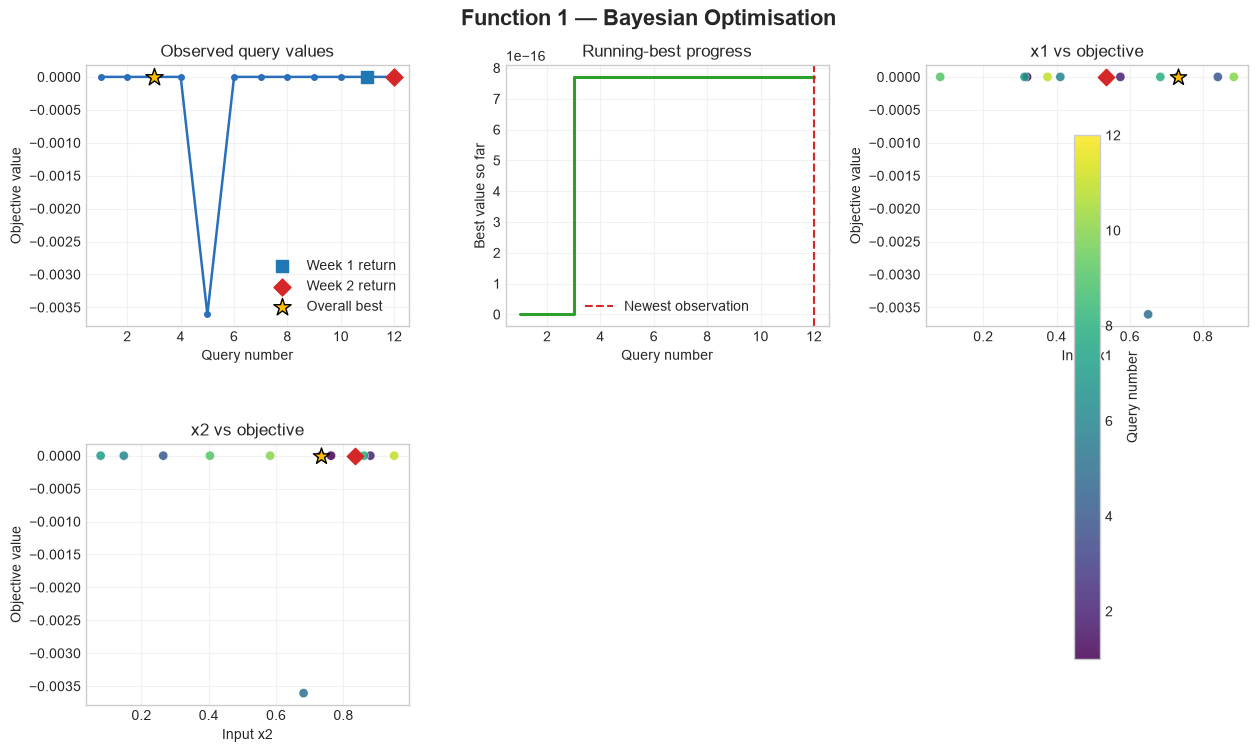

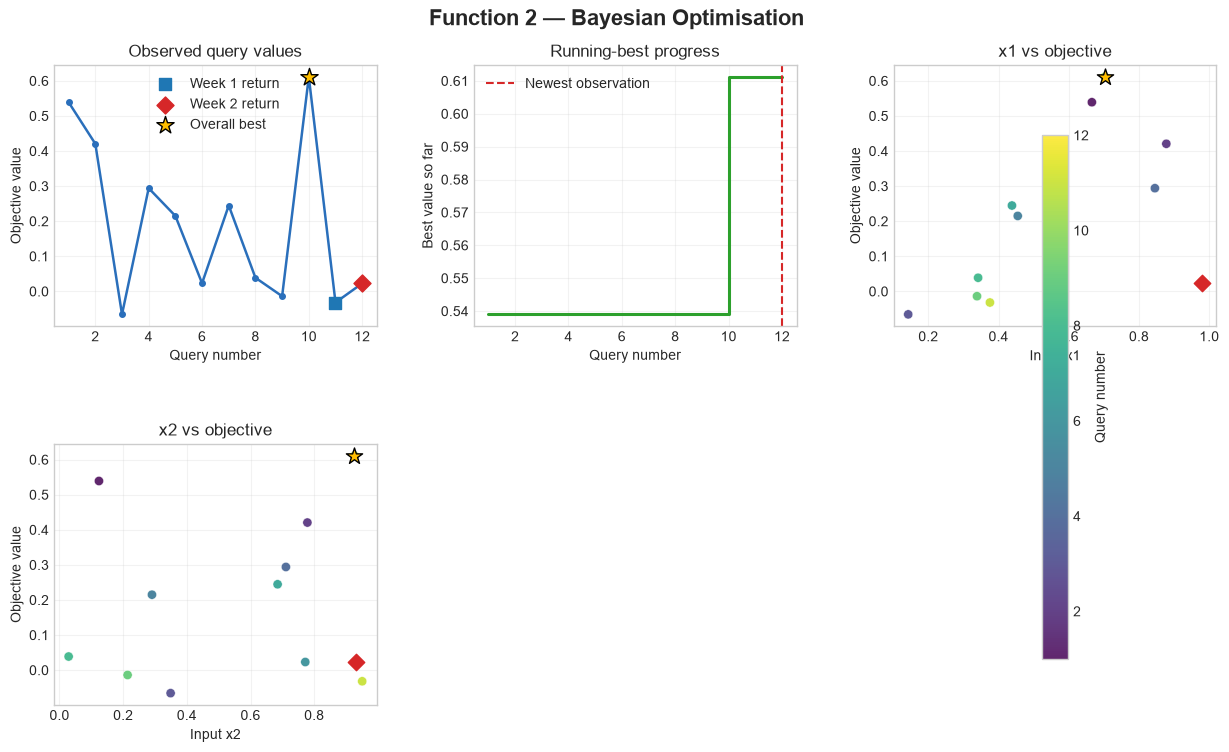

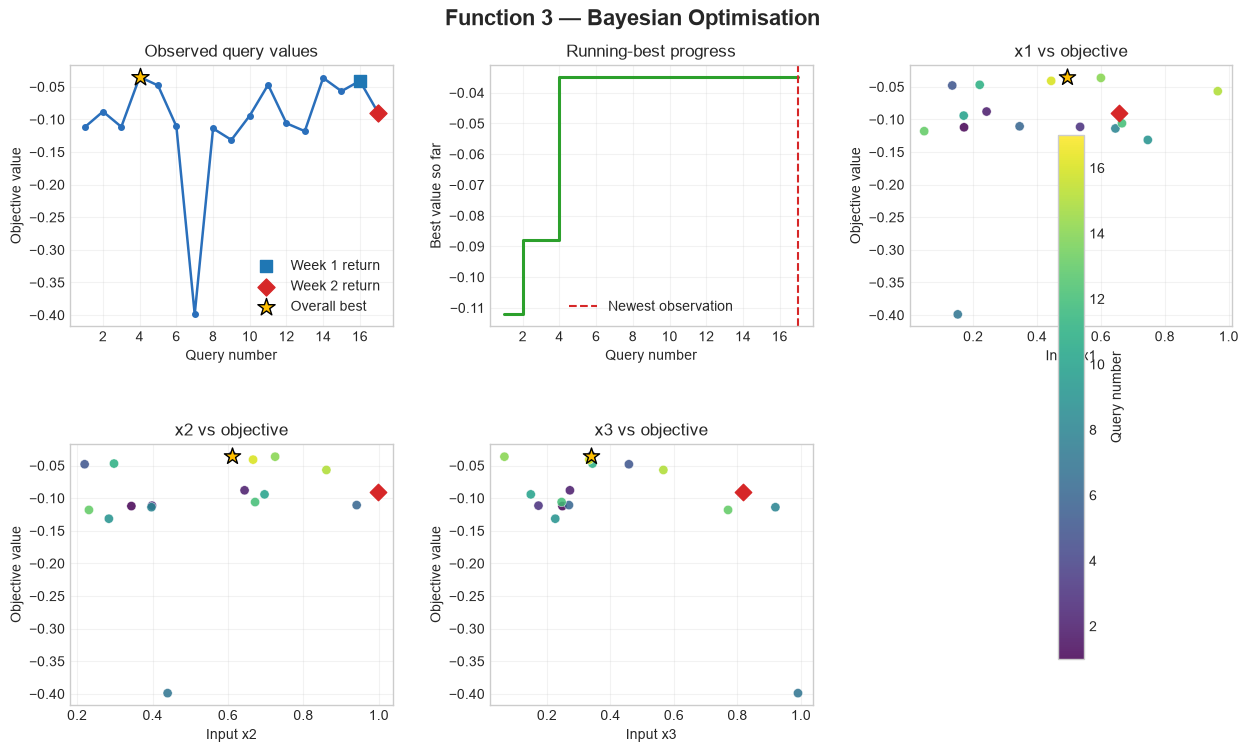

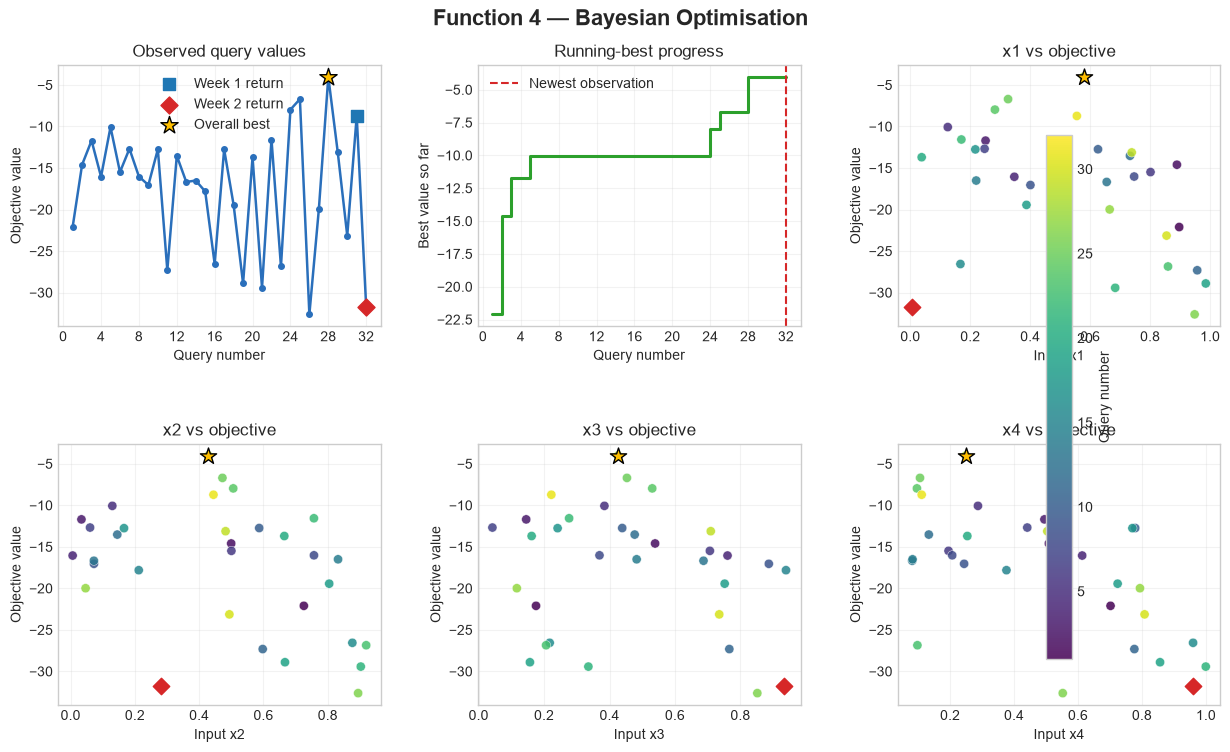

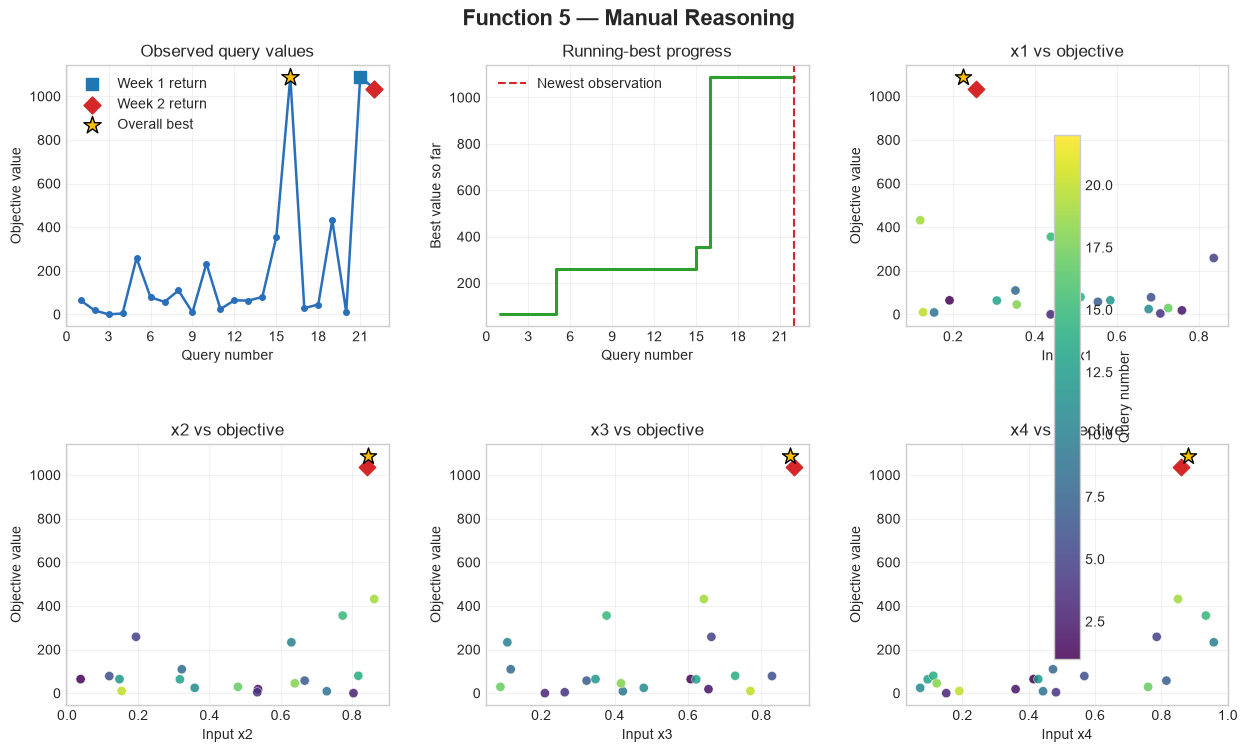

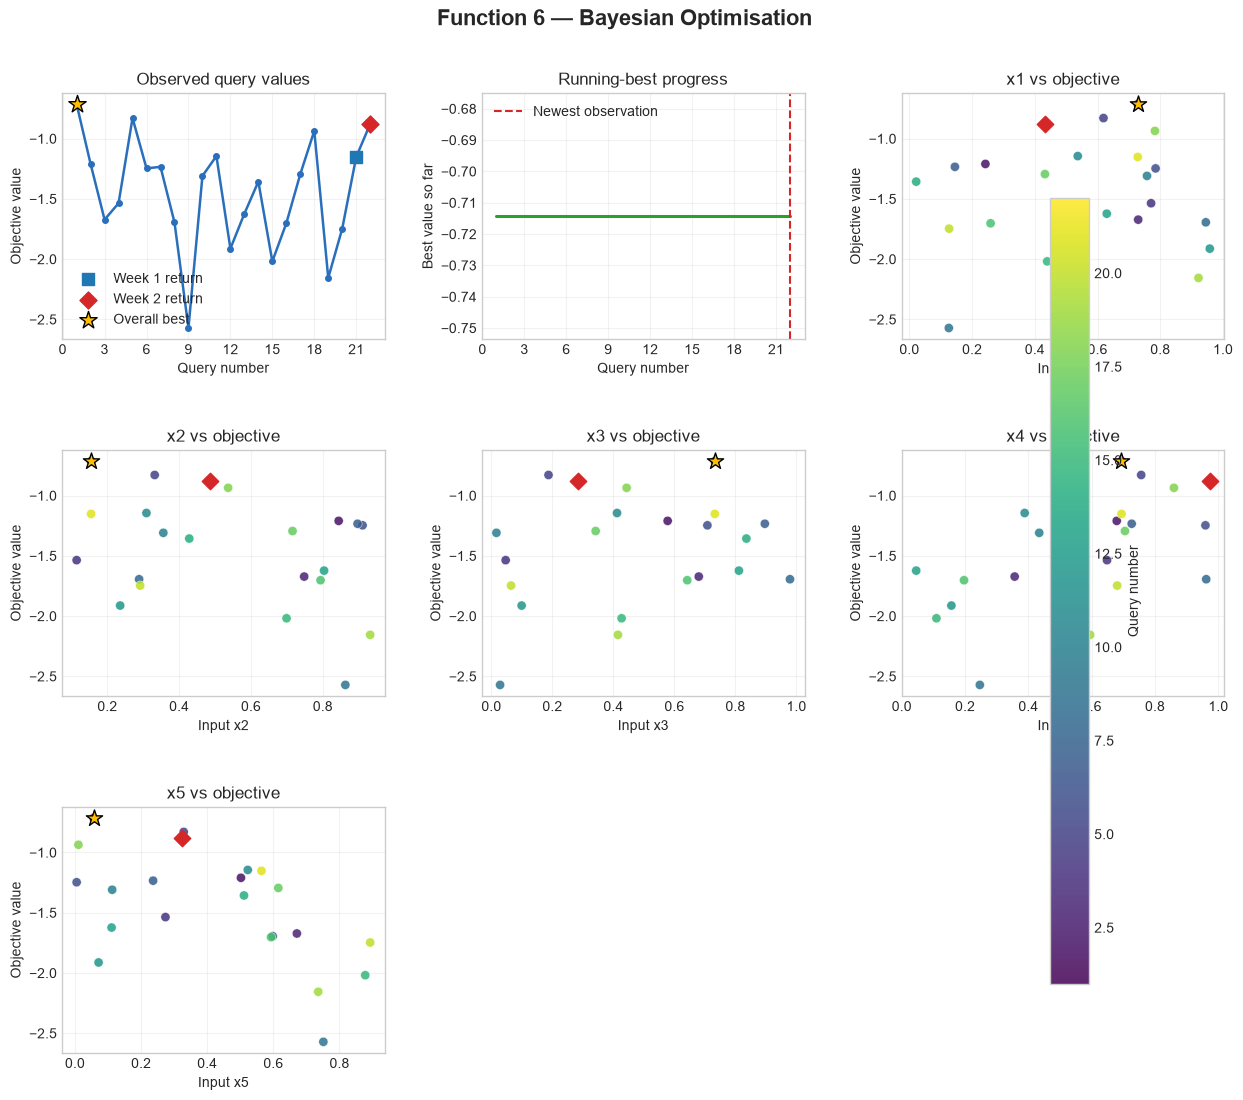

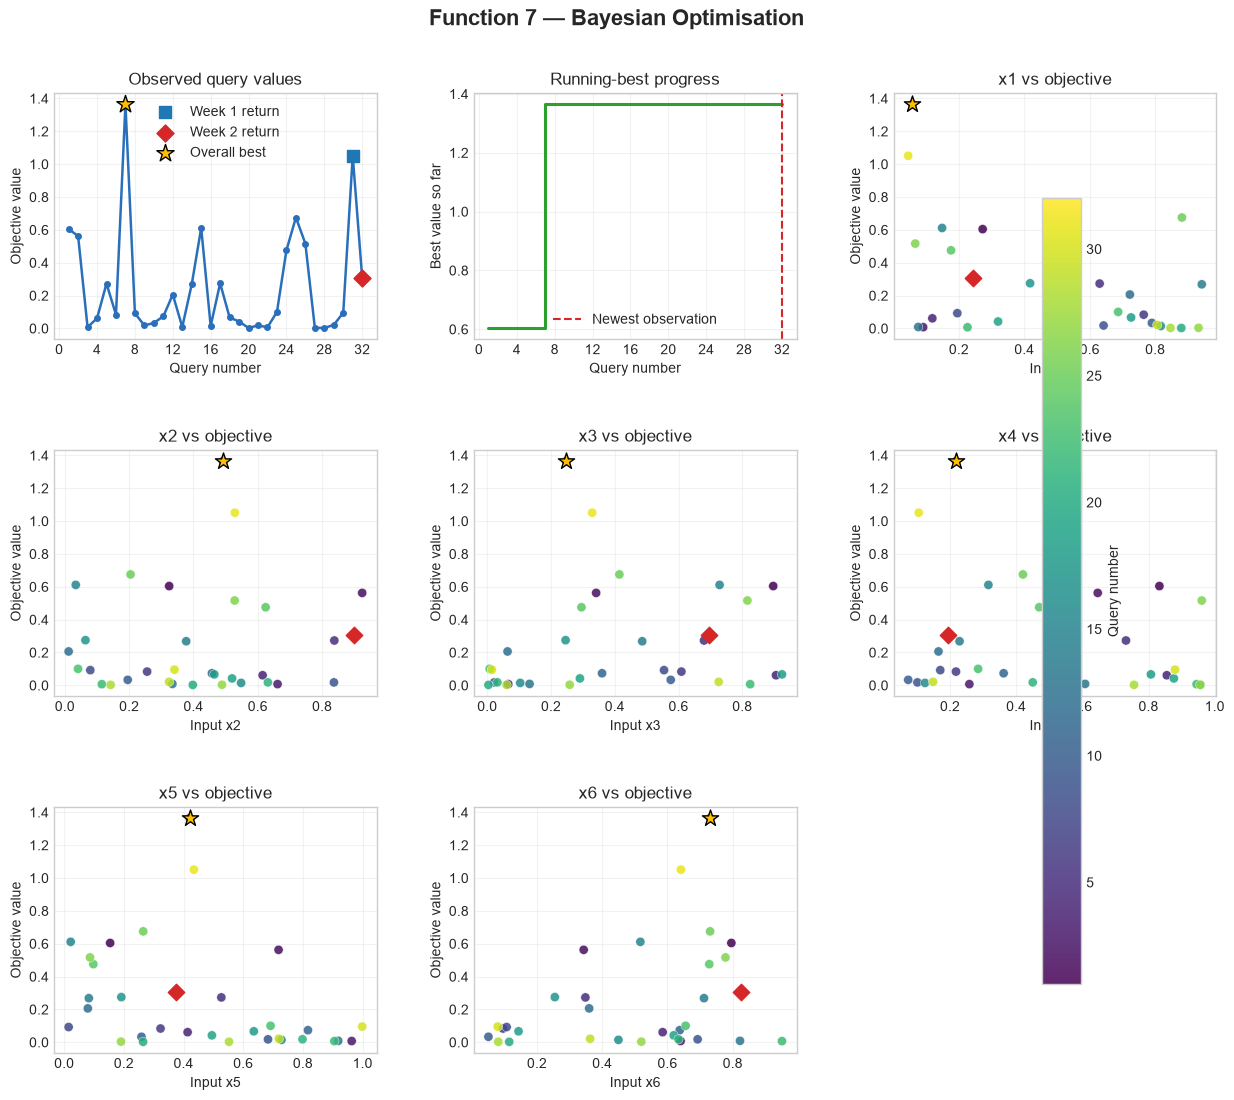

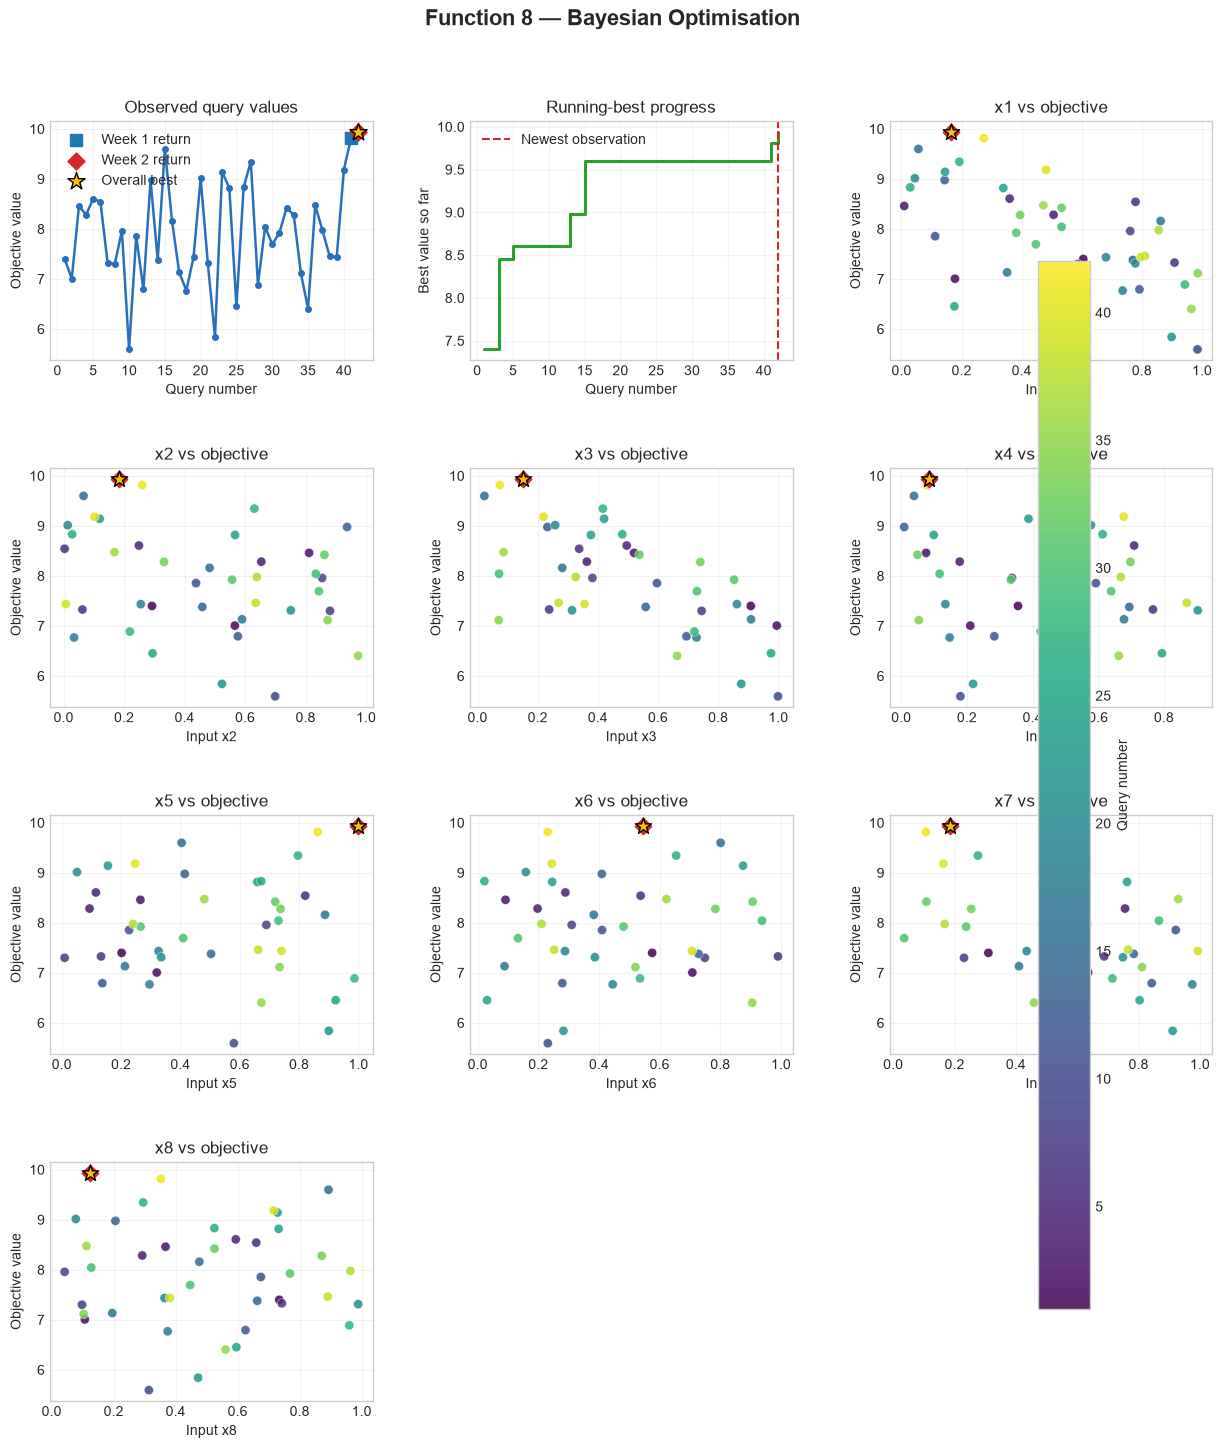

Rendered 8 function diagnostic figures.


In [7]:
def plot_function(function_number):
    X, y = load_week_3_data(function_number)
    q = np.arange(1, y.size + 1); best = int(np.argmax(y))
    panels, columns = X.shape[1] + 2, 3; rows = math.ceil(panels / columns)
    fig, axes = plt.subplots(rows, columns, figsize=(15, 4 * rows), squeeze=False); axes = axes.ravel()
    axes[0].plot(q, y, color='#2a6fbb', marker='o', linewidth=1.8, markersize=4)
    axes[0].scatter(q[-2], y[-2], marker='s', color='#1f77b4', s=70, zorder=4, label='Week 1 return')
    axes[0].scatter(q[-1], y[-1], marker='D', color='#d62728', s=75, zorder=4, label='Week 2 return')
    axes[0].scatter(q[best], y[best], marker='*', color='#ffbf00', edgecolor='black', s=170, zorder=5, label='Overall best')
    axes[0].set(xlabel='Query number', ylabel='Objective value', title='Observed query values'); axes[0].legend()
    axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
    running = np.maximum.accumulate(y); axes[1].step(q, running, where='post', color='#2ca02c', linewidth=2.2)
    axes[1].axvline(q[-1], color='#d62728', linestyle='--', label='Newest observation')
    axes[1].set(xlabel='Query number', ylabel='Best value so far', title='Running-best progress'); axes[1].legend()
    axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))
    colour = None
    for column, axis in enumerate(axes[2:2 + X.shape[1]]):
        colour = axis.scatter(X[:, column], y, c=q, cmap='viridis', s=44, alpha=.85, edgecolor='white', linewidth=.35)
        axis.scatter(X[-1, column], y[-1], marker='D', color='#d62728', s=70, zorder=4)
        axis.scatter(X[best, column], y[best], marker='*', color='#ffbf00', edgecolor='black', s=150, zorder=5)
        axis.set(xlabel=f'Input x{column + 1}', ylabel='Objective value', title=f'x{column + 1} vs objective')
    for axis in axes[panels:]: axis.set_visible(False)
    for axis in axes[:panels]: axis.grid(True, alpha=.25)
    fig.colorbar(colour, ax=axes[2:2 + X.shape[1]].tolist(), label='Query number', shrink=.85)
    fig.suptitle(f'Function {function_number} — {STRATEGY[function_number]}', fontsize=16, fontweight='bold')
    fig.subplots_adjust(top=.91, hspace=.45, wspace=.30)
    return fig

function_figures = [plot_function(i) for i in FUNCTIONS]
plt.show()
print(f'Rendered {len(function_figures)} function diagnostic figures.')

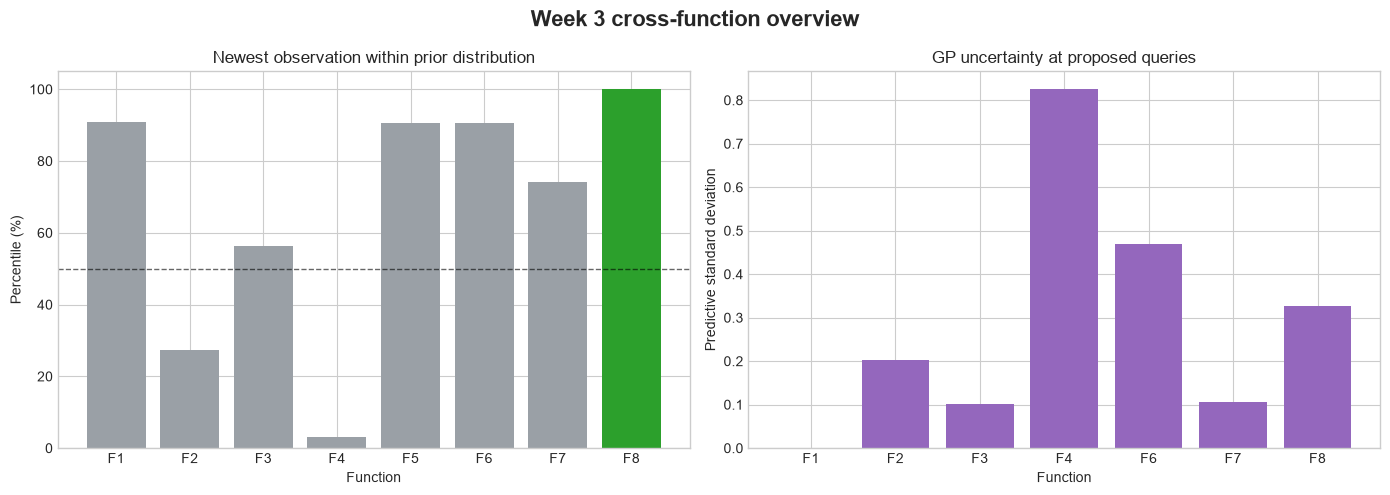

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colours = np.where(performance_summary['Improvement'] > 0, '#2ca02c', '#9aa0a6')
axes[0].bar(performance_summary['Function'], performance_summary['New-observation percentile'], color=colours)
axes[0].axhline(50, color='black', linestyle='--', linewidth=1, alpha=.6)
axes[0].set(title='Newest observation within prior distribution', xlabel='Function', ylabel='Percentile (%)', ylim=(0, 105))
gp = proposal_summary['Method'].eq('Bayesian Optimisation')
axes[1].bar(proposal_summary.loc[gp, 'Function'], proposal_summary.loc[gp, 'Predictive std'], color='#9467bd')
axes[1].set(title='GP uncertainty at proposed queries', xlabel='Function', ylabel='Predictive standard deviation')
fig.suptitle('Week 3 cross-function overview', fontsize=16, fontweight='bold'); fig.tight_layout(); plt.show()

<a id="reproducibility-checks"></a>
## 10. Reproducibility checks

In [9]:
expected_counts = {1: 12, 2: 12, 3: 17, 4: 32, 5: 22, 6: 22, 7: 32, 8: 42}
for function_number in FUNCTIONS:
    X, y = load_week_3_data(function_number); summary = summarize(function_number)
    assert X.shape == (expected_counts[function_number], DIMENSIONS[function_number])
    assert y.shape == (expected_counts[function_number],)
    assert np.allclose(X[-2], ROUND_QUERIES[function_number][1]) and np.allclose(X[-1], ROUND_QUERIES[function_number][2])
    assert np.isclose(y[-2], ROUND_OUTPUTS[function_number][1]) and np.isclose(y[-1], ROUND_OUTPUTS[function_number][2])
    assert summary['Best query'] == int(np.argmax(y)) + 1 and summary['Improvement'] >= 0
    assert function_number in submission_queries
assert sum(expected_counts.values()) == 191
assert len(performance_summary) == len(proposal_summary) == len(submission_queries) == 8
print('All Week 3 data, performance, proposal, and plotting checks passed.')

All Week 3 data, performance, proposal, and plotting checks passed.


<a id="conclusions-next-steps"></a>
## 11. Conclusions and next steps

The validated Week 3 workflow preserves observed evidence separately from proposed next queries and provides the handoff to the following round.